# Importing Necessary Libraries

In [1]:
# Basic Imports
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model and Metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans


from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# For saving the model
import joblib

# Loading the Dataset


In [ ]:
try:
    df = pd.read_csv("data/food.csv")
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'data/food.csv' not found. Please ensure the file is in the 'data' folder.")

Dataset loaded successfully!


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,Time_Order_picked,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,0,Urban,24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,0,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,0,Urban,26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,0,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,0,Metropolitian,30


# Data Preprocessing
### Checking for Missing Values

In [6]:
data = df.copy()
data.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Ordered                   0
Time_Order_picked              0
Weather                        0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken                     0
dtype: int64

### Calculating the Haversine Distance

In [7]:
def haversine_distance(df):
    R = 6371.0 # Earth radius in km
    lat1, lon1 = np.radians(df['Restaurant_latitude']), np.radians(df['Restaurant_longitude'])
    lat2, lon2 = np.radians(df['Delivery_location_latitude']), np.radians(df['Delivery_location_longitude'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

data['distance_km'] = haversine_distance(data)


### Clearing Whitespaces

In [8]:
str_cols = ['Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'City', 'Weather']
for col in str_cols:
    data[col] = data[col].astype(str).str.strip()

### Time Feature Extraction

In [9]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], dayfirst=True)
data['Order_day_of_week'] = data['Order_Date'].dt.dayofweek
data['Hour'] = pd.to_numeric(data['Time_Ordered'].astype(str).str.split(':').str[0], errors='coerce')


### Engineering New Features

In [10]:
# Converting to datetime objects
data['Time_Ordered'] = pd.to_datetime(data['Time_Ordered'], errors='coerce')
data['Time_Order_picked'] = pd.to_datetime(data['Time_Order_picked'], errors='coerce')

# Creating a New Feature - Prep Time
data['prep_time'] = (data['Time_Order_picked'] - data['Time_Ordered']).dt.total_seconds() / 60
data['prep_time'] = data['prep_time'].fillna(data['prep_time'].median())

# Creating a new feature - rush hour
data['Hour'] = data['Time_Ordered'].dt.hour
data['is_rush_hour'] = data['Hour'].apply(lambda x: 1 if x in [8, 9, 12, 13, 19, 20, 21] else 0)

C:\Users\phgtk\AppData\Local\Temp\ipykernel_15936\4087409619.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Time_Ordered'] = pd.to_datetime(data['Time_Ordered'], errors='coerce')
C:\Users\phgtk\AppData\Local\Temp\ipykernel_15936\4087409619.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Time_Order_picked'] = pd.to_datetime(data['Time_Order_picked'], errors='coerce')


### Dropping Irrelevant Columns

In [11]:
cols_to_drop = ['ID', 'Delivery_person_ID', 'Time_Order_picked', 'Time_Ordered', 'Order_Date']
data = data.drop(columns=cols_to_drop, errors='ignore')

print("Feature engineering complete: Time features extracted.")

Feature engineering complete: Time features extracted.


## Transformed Data 

In [12]:
data

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken,distance_km,Order_day_of_week,Hour,prep_time,is_rush_hour
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0,0,Urban,24,3.025149,5,11,15.0,0
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1,0,Metropolitian,33,20.183530,4,19,5.0,1
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,motorcycle,1,0,Urban,26,1.552758,5,8,15.0,1
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,motorcycle,1,0,Metropolitian,21,7.790401,1,18,10.0,0
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,scooter,1,0,Metropolitian,30,6.210138,5,13,15.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38059,35,4.2,23.371292,85.327872,23.481292,85.437872,Windy,Jam,2,Drinks,motorcycle,1,0,Metropolitian,33,16.600272,1,21,10.0,1
38060,30,4.8,26.902328,75.794257,26.912328,75.804257,Windy,High,1,Meal,motorcycle,0,0,Metropolitian,32,1.489846,3,11,10.0,0
38061,30,4.9,13.022394,80.242439,13.052394,80.272439,Cloudy,Low,1,Drinks,scooter,0,0,Metropolitian,16,4.657195,4,23,-1425.0,0
38062,20,4.7,11.001753,76.986241,11.041753,77.026241,Cloudy,High,0,Snack,motorcycle,1,0,Metropolitian,26,6.232393,0,13,5.0,1


# Predicting ETA with Regression

### Comparing Different Regression Models

In [13]:
X = data.drop(['Time_taken'], axis=1)
y = data['Time_taken']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

str_cols = ['Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'City', 'Weather']
numeric_features = [c for c in X.columns if c not in str_cols]

#Preprocessor
categories = [
    ['Low', 'Medium', 'High', 'Jam'],
    ['Drinks', 'Snack', 'Meal', 'Buffet'],
    ['motorcycle', 'scooter', 'electric_scooter'],
    ['Semi-Urban', 'Urban', 'Metropolitian'],
    ['Sunny', 'Windy', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog']
]

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=categories, handle_unknown='use_encoded_value', unknown_value=-1), str_cols),
        ('num', StandardScaler(), numeric_features)
    ]
)

print("Data split and Preprocessor redefined successfully!")

Data split and Preprocessor redefined successfully!


In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}


results = []
for name, model in models.items():
    # We use a pipeline here for each model to prevent leakage during comparison
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), # Reusing the preprocessor defined earlier
        ('regressor', model)
    ])
    
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({'Model': name, 'R2_Score': r2, 'RMSE': rmse})
    print(f"{name} evaluated.")


Linear Regression evaluated.
SVR evaluated.
Decision Tree evaluated.
Random Forest evaluated.


### Visualising the Results

,Model,R2_Score,RMSE
3,Random Forest,0.832628,3.825916
2,Decision Tree,0.686336,5.237534
1,SVR,0.642336,5.592832
0,Linear Regression,0.578349,6.072543


C:\Users\phgtk\AppData\Local\Temp\ipykernel_15936\701521726.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2_Score', data=results_df, palette='Blues_d')


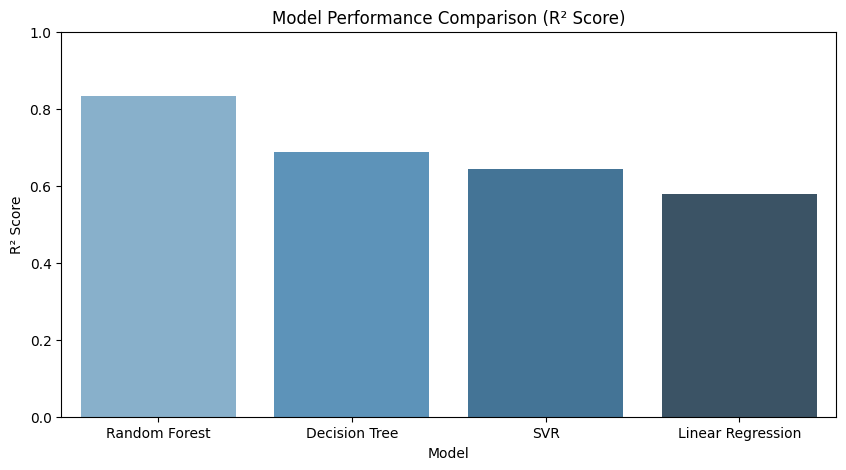

In [15]:
results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)
display(results_df)
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2_Score', data=results_df, palette='Blues_d')
plt.title('Model Performance Comparison (R² Score)')
plt.ylabel('R² Score')
plt.ylim(0, 1) # Set scale to 0-1 for a professional view
plt.show()

### Running our Best Model

In [16]:
best_model = RandomForestRegressor(n_estimators=100, random_state=42)

final_eta_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Re-using the preprocessor defined earlier
    ('model', best_model)
])

final_eta_pipeline.fit(X_train, y_train)

y_pred_final = final_eta_pipeline.predict(X_test)
print(f"Final Random Forest R2 Score: {r2_score(y_test, y_pred_final):.4f}")


Final Random Forest R2 Score: 0.8326


In [50]:
joblib.dump(final_eta_pipeline, 'models/eta_model.joblib')
print("Pipeline exported successfully to models/eta_model.joblib")

Pipeline exported successfully to models/eta_model.joblib


### Visualising our Best Model

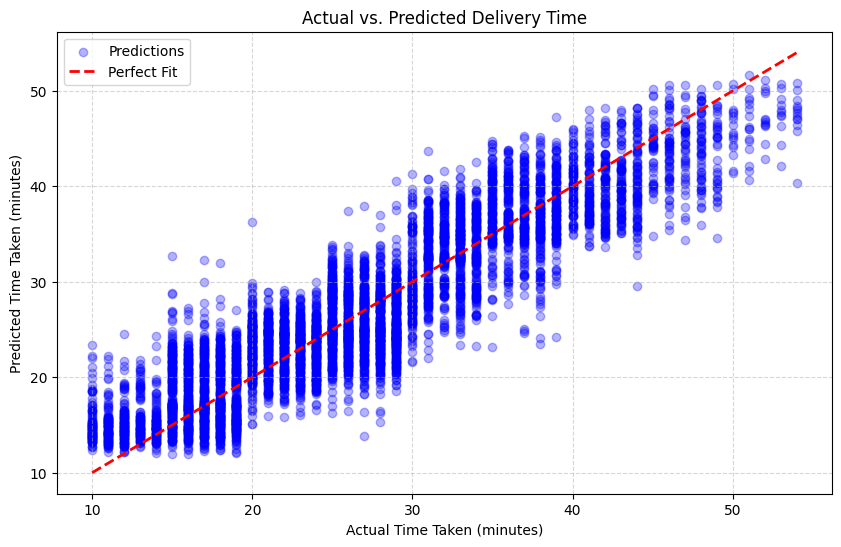

In [17]:
y_pred_final = final_eta_pipeline.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.3, color='blue', label='Predictions')

min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual vs. Predicted Delivery Time')
plt.xlabel('Actual Time Taken (minutes)')
plt.ylabel('Predicted Time Taken (minutes)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Surge Fees Classification

### Clustering the Data into Zones based on Geographical Features

Zone Distribution
Zone_ID
6     4340
13    3532
3     3137
2     2905
1     2880
4     2878
8     2860
14    2839
7     2835
12    2715
Name: count, dtype: int64


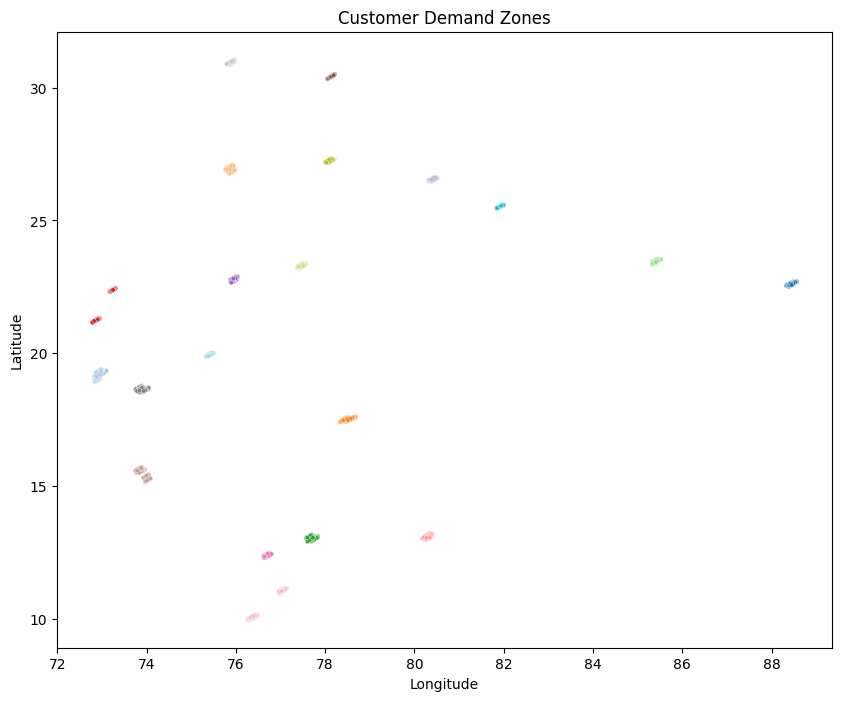

In [18]:
coords = df[['Delivery_location_latitude', 'Delivery_location_longitude']].copy()
valid_coords = coords[(coords['Delivery_location_latitude'] != 0) & (coords['Delivery_location_longitude'] != 0)]

zone_scaler = StandardScaler()
scaled_coords = zone_scaler.fit_transform(valid_coords)

kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
kmeans.fit(scaled_coords)
df.loc[valid_coords.index, 'Zone_ID'] = kmeans.labels_
df['Zone_ID'] = df['Zone_ID'].fillna(-1).astype(int)
print("Zone Distribution")
print(df['Zone_ID'].value_counts().head(10))

#Visualizing the Clusters
plt.figure(figsize=(10, 8))
valid_data = df[df['Zone_ID'] != -1]
sns.scatterplot(x='Delivery_location_longitude', y='Delivery_location_latitude', hue='Zone_ID', data=valid_data, palette='tab20', s=10, legend=False)
plt.title('Customer Demand Zones')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [54]:
# Save Model
joblib.dump({'model': kmeans, 'scaler': zone_scaler}, 'models/zone_cluster_model.joblib')
print("Zone clustering bundle saved.")

Zone clustering bundle saved.


### Creating Historical Features - Demand Last Hour and Demand Yesterday Same Hour

In [19]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Order_day'] = df['Order_Date'].dt.day
df['Order_month'] = df['Order_Date'].dt.month
df['Order_year'] = df['Order_Date'].dt.year
df['Order_day_of_week'] = df['Order_Date'].dt.dayofweek
df['Hour'] = pd.to_numeric(df['Time_Ordered'].astype(str).str.split(':').str[0], errors='coerce')
df_agg = df[df['Zone_ID'] != -1].groupby(['Zone_ID','Order_day_of_week', 'Hour']).agg(Actual_Demand=('ID', 'count'), Avg_Delivery_Time=('Time_taken', 'mean'),Avg_Rating=('Delivery_person_Ratings', 'mean')  ).reset_index()
df_agg = df_agg.sort_values(by=['Zone_ID', 'Hour'])
df_agg['Demand_Last_Hour'] = df_agg.groupby('Zone_ID')['Actual_Demand'].shift(1)
df_agg['Demand_Yesterday_Same_Hour'] = df_agg.groupby('Zone_ID')['Actual_Demand'].shift(24)
df_agg = df_agg.dropna()
print("Aggregated Data Ready for Forecasting")
print(df_agg.head())
print(f"\nTotal training samples: {len(df_agg)}")

Aggregated Data Ready for Forecasting
    Zone_ID  Order_day_of_week  Hour  Actual_Demand  Avg_Delivery_Time  \
36        0                  3    13              1              34.00   
52        0                  4    13              5              28.60   
76        0                  6    13              4              27.25   
14        0                  1    14              2              35.50   
37        0                  3    14              1              33.00   

    Avg_Rating  Demand_Last_Hour  Demand_Yesterday_Same_Hour  
36         4.0               1.0                         1.0  
52         4.6               1.0                         2.0  
76         4.6               5.0                         1.0  
14         4.5               4.0                        10.0  
37         5.0               2.0                         5.0  

Total training samples: 1610


### Predicting the Next Hour Demand

In [20]:
df_agg['Traffic_Last_Hour'] = df_agg.groupby('Zone_ID')['Avg_Delivery_Time'].shift(1)
demand_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

features = ['Zone_ID', 'Hour', 'Demand_Last_Hour', 'Demand_Yesterday_Same_Hour', 'Traffic_Last_Hour','Order_day_of_week']
X = df_agg[features]
y = df_agg['Actual_Demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

demand_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(random_state=42))])

In [57]:
joblib.dump(demand_pipeline, 'models/demand_model.joblib')
joblib.dump(features, 'models/demand_features.joblib')

print("Demand model and feature list saved.")

Demand model and feature list saved.


### Decision Regarding Surge Fees

In [21]:
#Calculate Thresholds
zone_capacity = df_agg.groupby('Zone_ID')['Actual_Demand'].quantile(0.75).to_dict()
zone_capacity


{0: 10.5,
 1: 40.5,
 2: 42.5,
 3: 46.0,
 4: 39.0,
 5: 34.0,
 6: 64.0,
 7: 40.0,
 8: 41.5,
 9: 10.0,
 10: 9.0,
 11: 9.0,
 12: 38.0,
 13: 51.0,
 14: 41.0,
 15: 11.0,
 16: 9.5,
 17: 7.25,
 18: 9.25,
 19: 8.0}

### Predicting Demand for Next hour and Applying Surge Fees

In [23]:
df_agg['Traffic_Last_Hour'] = df_agg.groupby('Zone_ID')['Avg_Delivery_Time'].shift(1)
features = ['Zone_ID', 'Hour', 'Demand_Last_Hour', 'Demand_Yesterday_Same_Hour', 'Traffic_Last_Hour','Order_day_of_week']
X = df_agg[features]
y = df_agg['Actual_Demand']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Demand Forecasting Model Results")
print(f"Mean Absolute Error: {mae:.2f} orders") 
print(f"R2 Score: {r2:.4f}")

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPrediction Snapshot")
print(results_df.head().round(1))
zone_capacity = df_agg.groupby('Zone_ID')['Actual_Demand'].quantile(0.75).to_dict()

def get_surge_multiplier(predicted_demand, zone_id):
    threshold = zone_capacity.get(zone_id, 100) 
    if predicted_demand > threshold:
        if predicted_demand > (threshold * 1.2):
            return 1.5
        else:
            return 1.2
    else:
        return 1.0


simulation = X_test.copy()
simulation['Actual_Demand'] = y_test
simulation['Predicted_Demand'] = y_pred  


simulation['Surge_Multiplier'] = simulation.apply(
    lambda row: get_surge_multiplier(row['Predicted_Demand'], row['Zone_ID']), axis=1
)


base_fee = 10.00

# Calculate Revenue without Surge vs. Revenue with Surge
simulation['Revenue_Base'] = simulation['Actual_Demand'] * base_fee
simulation['Revenue_Dynamic'] = simulation['Actual_Demand'] * (base_fee * simulation['Surge_Multiplier'])

# Review Results
total_base_rev = simulation['Revenue_Base'].sum()
total_dynamic_rev = simulation['Revenue_Dynamic'].sum()
extra_revenue = total_dynamic_rev - total_base_rev

print("Surge Pricing Simulation")
print(f"Total Base Revenue:     Rs.{total_base_rev:,.2f}")
print(f"Total Dynamic Revenue:  Rs.{total_dynamic_rev:,.2f}")
print(f"Extra Revenue Generated: Rs.{extra_revenue:,.2f} (+{(extra_revenue/total_base_rev)*100:.1f}%)")

print("\n Look at Changes in Price Decisions")
# Show a few rows where Surge was triggered (Multiplier > 1.0)
print(simulation[simulation['Surge_Multiplier'] > 1.0][
    ['Zone_ID', 'Hour', 'Predicted_Demand', 'Surge_Multiplier']
].head())

Demand Forecasting Model Results
Mean Absolute Error: 4.55 orders
R2 Score: 0.8740

Prediction Snapshot
      Actual  Predicted
3         13       14.1
163        4        5.2
912        4        5.9
1825       7        3.6
247        6        7.0
Surge Pricing Simulation
Total Base Revenue:     Rs.70,220.00
Total Dynamic Revenue:  Rs.76,907.00
Extra Revenue Generated: Rs.6,687.00 (+9.5%)

 Look at Changes in Price Decisions
      Zone_ID  Hour  Predicted_Demand  Surge_Multiplier
3           0    19             14.08               1.5
1131       10    18             13.70               1.5
2061       19    19             12.99               1.5
2060       19    18             12.12               1.5
1099        9    17             16.44               1.5


In [60]:
#Export to JSON
import json
with open('C:/Users/phgtk/models/zone_thresholds.json', 'w') as f:
    json.dump(zone_capacity, f)

print("Surge thresholds saved to JSON.")

Surge thresholds saved to JSON.


# Clustering Drivers Based on Performance to get insights,

In [61]:
driver_profiles = df.groupby('Delivery_person_ID').agg({
    'Delivery_person_Age': 'mean',        # Add this line
    'Delivery_person_Ratings': 'mean',      
    'Time_taken': 'mean',                   
    'ID': 'count'                           
}).rename(columns={'ID': 'Total_Deliveries'})

# Now proceed with your existing clustering code...
driver_profiles = driver_profiles[driver_profiles['Total_Deliveries'] > 5]

driver_scaler = StandardScaler()
features_to_cluster = ['Delivery_person_Ratings', 'Time_taken', 'Total_Deliveries']
scaled_driver_features = driver_scaler.fit_transform(driver_profiles[features_to_cluster])

driver_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
driver_kmeans.fit(scaled_driver_features)
driver_profiles


,Delivery_person_Age,Delivery_person_Ratings,Time_taken,Total_Deliveries
Delivery_person_ID,,,,
AGRRES010DEL01,31.000000,4.761538,24.307692,13
AGRRES010DEL02,29.000000,4.671429,28.357143,14
AGRRES010DEL03,29.250000,4.575000,28.416667,12
AGRRES01DEL01,30.777778,4.522222,28.777778,9
AGRRES01DEL02,30.571429,4.700000,24.428571,14
...,...,...,...,...
VADRES19DEL02,28.672727,4.632727,26.636364,55
VADRES19DEL03,29.378378,4.670270,26.405405,37
VADRES20DEL01,30.648148,4.620370,27.425926,54


In [64]:
joblib.dump({'model': driver_kmeans, 'scaler': driver_scaler}, 'C:/Users/phgtk/models/driver_cluster_model.joblib')
print("Driver profiling bundle saved.")

Driver profiling bundle saved.


## Visualization and Insights

--- Cluster Profiles (Who are they?) ---
         Delivery_person_Age  Delivery_person_Ratings  Time_taken  \
Cluster                                                             
0                  29.366318                 4.698328   25.125115   
1                  29.605410                 4.630906   26.547073   
2                  29.974734                 4.568992   28.332357   

         Total_Deliveries  
Cluster                    
0               13.576642  
1               48.908948  
2               12.439216  


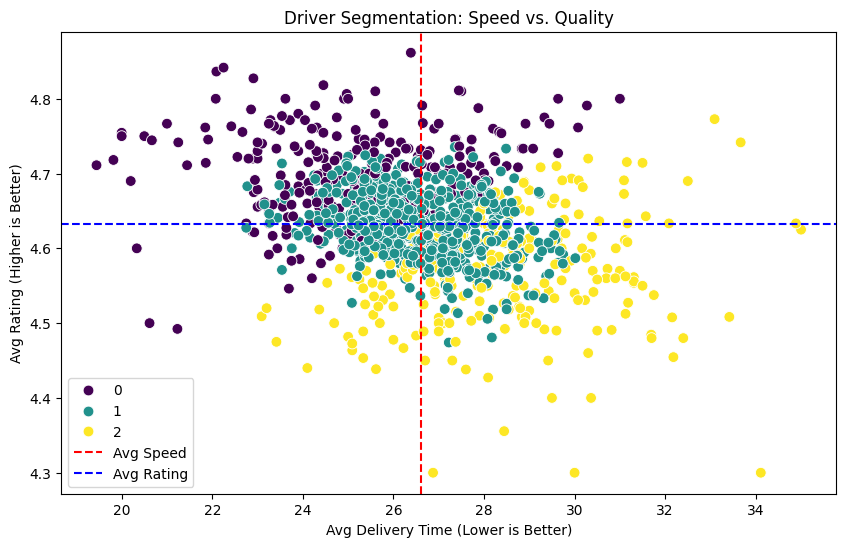


 HIRING INSIGHTS (Based on 'Best' Cluster 0)
The 'Star Drivers' make up 274 people.
Their Common Traits:
- Average Age: 29.4 years old
- Consistency: They have completed avg 14 deliveries


In [65]:

driver_profiles['Cluster'] = driver_kmeans.fit_predict(scaled_driver_features)


cluster_analysis = driver_profiles.groupby('Cluster').mean().sort_values(by='Delivery_person_Ratings', ascending=False)

print("--- Cluster Profiles (Who are they?) ---")
print(cluster_analysis)



plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=driver_profiles, 
    x='Time_taken', 
    y='Delivery_person_Ratings', 
    hue='Cluster', 
    palette='viridis',
    s=60
)
plt.title('Driver Segmentation: Speed vs. Quality')
plt.xlabel('Avg Delivery Time (Lower is Better)')
plt.ylabel('Avg Rating (Higher is Better)')
plt.axvline(x=driver_profiles['Time_taken'].mean(), color='red', linestyle='--', label='Avg Speed')
plt.axhline(y=driver_profiles['Delivery_person_Ratings'].mean(), color='blue', linestyle='--', label='Avg Rating')
plt.legend()
plt.show()


best_cluster_id = cluster_analysis['Delivery_person_Ratings'].idxmax()
best_drivers = driver_profiles[driver_profiles['Cluster'] == best_cluster_id]

print(f"\n HIRING INSIGHTS (Based on 'Best' Cluster {best_cluster_id})")
print(f"The 'Star Drivers' make up {len(best_drivers)} people.")
print(f"Their Common Traits:")
print(f"- Average Age: {best_drivers['Delivery_person_Age'].mean():.1f} years old")
print(f"- Consistency: They have completed avg {best_drivers['Total_Deliveries'].mean():.0f} deliveries")